# Neutron reflectometry  (Normalizing Flow inference)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from reflectorch import EasyInferenceModel, interp_reflectivity

torch.manual_seed(0); # set seed for reproducibility

# Reproducing first example (Ni500.dat)

We consider the following NR data for a 1-layer stucture of Ni on Si (air as ambient), measured at a resolution dq/q = 0.1 (i.e. 10%):

In [2]:
data = np.loadtxt('exp_data/Ni500.dat', delimiter='\t', skiprows=0)
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]
sigmas_exp = data[..., 2]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())
print(sigmas_exp.shape, sigmas_exp.max(), sigmas_exp.min(), (sigmas_exp / curve_exp).max())

(174, 3)
(174,) (174,) 0.01333 0.22399
(174,) 8.83715e-05 4.23214e-07 0.3282606076124776


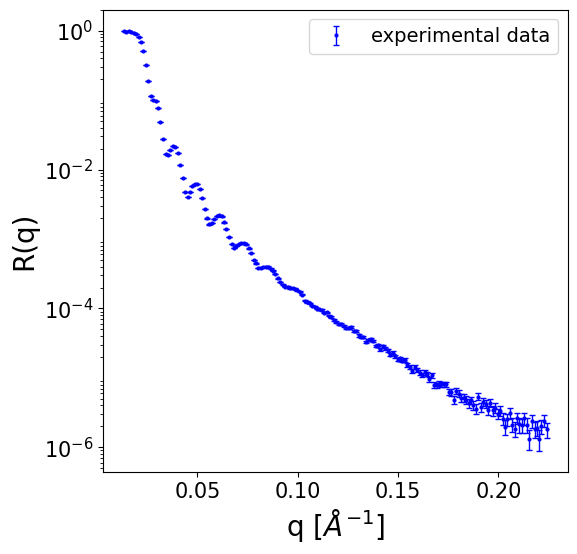

In [3]:
fig, ax = plt.subplots(1,1,figsize=(6,6))

ax.set_yscale('log')
ax.set_xlabel('q [$Å^{-1}$]', fontsize=20)
ax.set_ylabel('R(q)', fontsize=20)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='minor', labelsize=15)

y_tick_locations = [10**(-2*i) for i in range(6)]
ax.yaxis.set_major_locator(plt.FixedLocator(y_tick_locations))

el = ax.errorbar(q_exp, curve_exp, fmt='o', markersize=2, linewidth=1,zorder=2,
                 yerr=sigmas_exp, xerr=None, color='blue', ecolor='blue', elinewidth=1, capsize=2, barsabove=False,
                 label='experimental data')
elines = el.get_children()
elines[1].set_color('green')

ax.legend(loc='upper right', fontsize=14)

We initialize an inference object for a model trained for neutron reflectometry and a standard parameterization with 1 layer (for more details on the `EasyInferenceModel` class see the previous tutorial):

# Note: this notebook may fail to execute with the mixed config if not run in the root directory

In [4]:
config_name = 'nf_config_mixed_mean_conditioned.yaml'

inference_model = EasyInferenceModel(config_name=config_name,
                                     device='cpu',
                                     weights_format='pt'
                                     )

Configuration file `/home/levytskyi/Documents/reflectorch_devvm/reflectorch/configs/nf_config_mixed_mean_conditioned.yaml` found locally.
Weights file `/home/levytskyi/Documents/reflectorch_devvm/reflectorch/saved_models/model_nf_config_mixed_mean_conditioned.pt` found locally.
Model nf_config_mixed_mean_conditioned.yaml loaded. Number of parameters: 40.91 M
The model corresponds to a `standard_model` parameterization with 1 layers (7 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 1500.0]
- roughnesses: [0.0, 60.0]
- slds: [-8.0, 16.0]
- r_scale: [0.9, 1.1]
- log10_background: [-10.0, -4.0]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 1500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 24.0]
- r_scale: [0.001, 0.2]
- log10_background: [0.01, 6.0]
The model was trained on curves discretized at 256 uniform points between q_min=0.007 and q_max=0.284
The model was trained with linear resolution smearing (dq/q) in the range [0.01,

We interpolate the data to a discretization suitable for this model:

In [5]:
q_model, exp_curve_interp = inference_model.interpolate_data_to_model_q(q_exp, curve_exp)

print(q_model.shape, q_model.min(), q_model.max())
print(exp_curve_interp.shape)

(256,) 0.007 0.284
(256,)


We set some prior bounds for the parameters:

In [6]:
# adding parameters from training: r_scale: [0.9, 1.1], log10_background: [-10.0, -4.0]

prior_bounds = [(300., 900.), #layer thicknesses (top to bottom)
                (0., 20.), (0., 20.), #interlayer roughnesses (top to bottom)
                (9., 11.), (3., 5.), #real layer slds: Ni, glass
                (0.9, 1.1), (-10.0, -4.0)] 

For performing the prediction we need to provide the `q_resolution` argument. When this argument is a *float*, its meaning is dq/q. This value is always used for simulating the reflectivity curve corresponding to the predicted parameters and as a keyword argument to the reflectivity function during polishing. Depending on the training scenario, it might also be used as an additional input to the network.

# Performing inference

In [7]:
# exp_curve_interp = exp_curve_interp.astype(np.float32)
# q_model = q_model.astype(np.float32)

prediction_dict = inference_model.preprocess_and_sample(reflectivity_curve=exp_curve_interp,q_values=q_model, num_samples=1000, prior_bounds=prior_bounds, q_resolution=0.1, calc_sampled_curves=True, calc_sampled_sld_profiles=True)


################################################################################
### STARTING INFERENCE SAMPLE() METHOD ###
################################################################################

[sample] Prior bounds shape: (7, 2)
[sample] Scaled prior bounds dtype: torch.float32, shape: torch.Size([1, 14])

[sample] ========== PREPROCESSING INPUTS ==========

[sample] Using ConstantQ generator

[sample] Calling _scale_curve()...
[sample] scaled_curve output:
  - dtype: torch.float32, shape: torch.Size([1, 256])
  - range: [-6.174757e-02, 9.382510e-01]

[sample] Computing scaled_q_values (train_with_q_input=True)...
  - Before dtype conversion: torch.float64
  - After dtype conversion: torch.float32
  - shape: torch.Size([1, 256])
  - range: [-1.000000e+00, 1.000000e+00]

[sample] scaled_sigmas = None (train_with_sigmas=False, sigmas=None)
[DEBUG] q_resolution is scalar: 0.1
[DEBUG] scaled_q_resolutions dtype: torch.float32
[DEBUG] FINAL scaled_conditioning_params dtype: to

/home/levytskyi/Documents/reflectorch_devvm/reflectorch/nfref_py310/lib/python3.10/site-packages/nflows/transforms/coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


In [8]:
prediction_dict.keys()

dict_keys(['predicted_params_object', 'predicted_params_array', 'param_names', 'sampled_curves', 'q_plot_pred', 'sampled_sld_profiles', 'sampled_sld_xaxis', 'q_model', 'reflectivity_curve_interp', 'q_resolution_interp'])

# Defining initial postprocessing function

In [9]:
def postprocess(prediction_dict):
    # Extract data
    sampled_curves = prediction_dict['sampled_curves']
    sampled_slds = prediction_dict['sampled_sld_profiles']
    sld_xaxis = prediction_dict['sampled_sld_xaxis']
    q_plot = prediction_dict['q_plot_pred']

    # Extract missing variables
    pred_params = prediction_dict['predicted_params_array']
    param_names = prediction_dict['param_names']

    # 1. Calculate and print Mean + Std Dev
    mean_params = np.mean(pred_params, axis=0)
    std_params = np.std(pred_params, axis=0)

    print(f"{'Parameter':<20} | {'Mean':<12} | {'Std Dev':<12}")
    print("-" * 50)
    for name, mean, std in zip(param_names, mean_params, std_params):
        print(f"{name:<20} | {mean:<12.4f} | {std:<12.4f}")


    # 2. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # --- Left Plot: Reflectivity ---
    ax[0].set_yscale('log')
    ax[0].set_xlabel('q [$Å^{-1}$]', fontsize=14)
    ax[0].set_ylabel('R(q)', fontsize=14)
    ax[0].set_title('Reflectivity', fontsize=16)

    # Plot experimental data
    ax[0].errorbar(q_exp, curve_exp, yerr=sigmas_exp, fmt='o', color='black', 
                markersize=3, alpha=0.6, label='Exp. Data', zorder=10)

    # Plot sampled curves
    for i, curve in enumerate(sampled_curves):
        label = "Predicted Samples" if i == 0 else None
        ax[0].plot(q_plot, curve, color='red', alpha=0.3, linewidth=1, label=label)

    ax[0].legend(fontsize=12)
    ax[0].grid(alpha=0.2, which='both')

    # --- Right Plot: SLD Profile ---
    ax[1].set_xlabel('z [$Å$]', fontsize=14)
    ax[1].set_ylabel('SLD [$10^{-6} Å^{-2}$]', fontsize=14)
    ax[1].set_title('SLD Profile', fontsize=16)

    # Plot sampled SLD profiles
    for i, sld in enumerate(sampled_slds):
        label = "Predicted Samples" if i == 0 else None
        ax[1].plot(sld_xaxis, sld, color='red', alpha=0.3, linewidth=1, label=label)

    ax[1].legend(fontsize=12)
    ax[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# Inference results

Parameter            | Mean         | Std Dev     
--------------------------------------------------
Thickness L1         | 394.0548     | 80.0740     
Roughness L1         | 4.8488       | 2.2565      
Roughness sub        | 7.1275       | 5.9815      
SLD L1               | 10.0282      | 0.5810      
SLD sub              | 4.0245       | 1.0520      
r_scale              | 0.9922       | 0.0048      
log10_background     | -6.2452      | 0.0367      


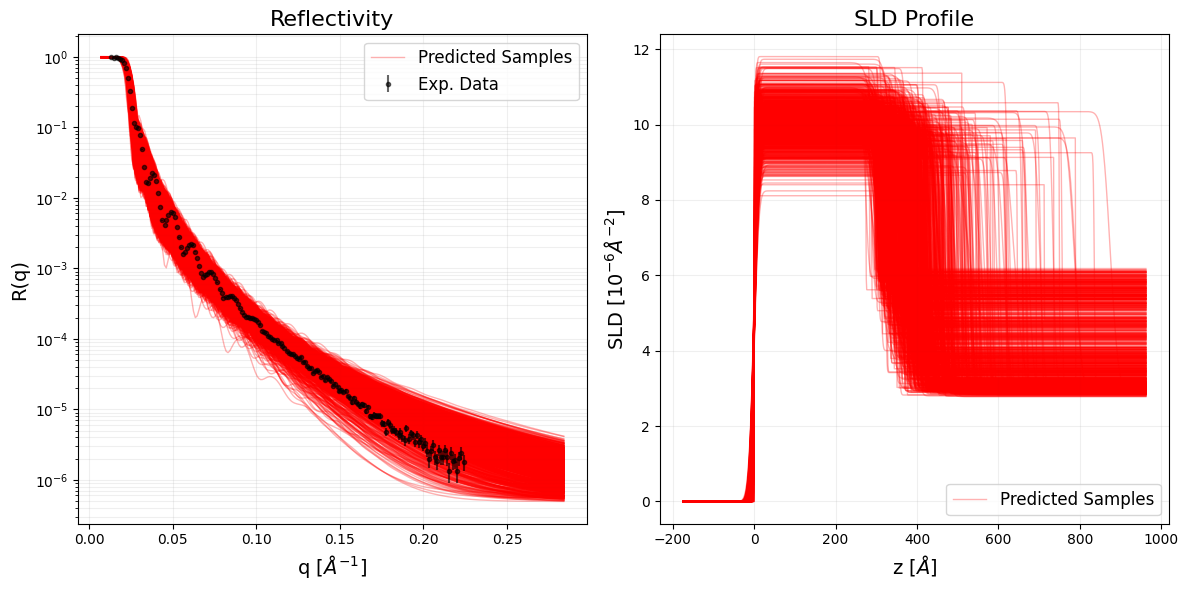

In [10]:
postprocess(prediction_dict)

In [ ]:
# Previous reflectorch results:

# Thickness L1   -> Predicted: 498.53       Polished: 497.37
# Roughness L1   -> Predicted: 6.45       Polished: 5.65
# Roughness sub  -> Predicted: 7.68       Polished: 9.39
# SLD L1         -> Predicted: 10.24       Polished: 10.24
# SLD sub        -> Predicted: 3.92       Polished: 3.87

# Testing on the second example (Ni on glass)

In [12]:
data = np.loadtxt('exp_data/Ni_on_glass.dat', delimiter='\t', skiprows=0)
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())


(757, 2)
(757,) (757,) 0.00508981 0.175655


In [ ]:
# inference model stays the same

In [13]:
prior_bounds = [
    (300., 900.), #layer thicknesses (top to bottom)
    (0., 20.), (0., 20.), #interlayer roughnesses (top to bottom)
    (9., 11.), (3., 5.), #layer slds: Ni, glass
    (0.9, 1.1), #intensity scaling factor
    (-10, -4), #log10 background
] 

In [14]:
q_model, exp_curve_interp = inference_model.interpolate_data_to_model_q(q_exp, curve_exp)

print(q_model.shape, q_model.min(), q_model.max())
print(exp_curve_interp.shape)

(256,) 0.007 0.284
(256,)


## Inference

In [15]:
prediction_dict = inference_model.preprocess_and_sample(
    reflectivity_curve=exp_curve_interp,
    q_values=q_model, 
    num_samples=1000, 
    prior_bounds=prior_bounds, 
    q_resolution=0.015, # was 0.1 in the previous example
    calc_sampled_curves=True, 
    calc_sampled_sld_profiles=True)


################################################################################
### STARTING INFERENCE SAMPLE() METHOD ###
################################################################################

[sample] Prior bounds shape: (7, 2)
[sample] Scaled prior bounds dtype: torch.float32, shape: torch.Size([1, 14])

[sample] ========== PREPROCESSING INPUTS ==========

[sample] Using ConstantQ generator

[sample] Calling _scale_curve()...
[sample] scaled_curve output:
  - dtype: torch.float32, shape: torch.Size([1, 256])
  - range: [-6.011904e-02, 9.460456e-01]

[sample] Computing scaled_q_values (train_with_q_input=True)...
  - Before dtype conversion: torch.float64
  - After dtype conversion: torch.float32
  - shape: torch.Size([1, 256])
  - range: [-1.000000e+00, 1.000000e+00]

[sample] scaled_sigmas = None (train_with_sigmas=False, sigmas=None)
[DEBUG] q_resolution is scalar: 0.015
[DEBUG] scaled_q_resolutions dtype: torch.float32
[DEBUG] FINAL scaled_conditioning_params dtype: 

## Adjusted postprocess function (error bars removed)

In [16]:
def postprocess(prediction_dict):
    # Extract data
    sampled_curves = prediction_dict['sampled_curves']
    sampled_slds = prediction_dict['sampled_sld_profiles']
    sld_xaxis = prediction_dict['sampled_sld_xaxis']
    q_plot = prediction_dict['q_plot_pred']

    # Extract missing variables
    pred_params = prediction_dict['predicted_params_array']
    param_names = prediction_dict['param_names']

    # 1. Calculate and print Mean + Std Dev
    mean_params = np.mean(pred_params, axis=0)
    std_params = np.std(pred_params, axis=0)

    print(f"{'Parameter':<20} | {'Mean':<12} | {'Std Dev':<12}")
    print("-" * 50)
    for name, mean, std in zip(param_names, mean_params, std_params):
        print(f"{name:<20} | {mean:<12.4f} | {std:<12.4f}")


    # 2. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # --- Left Plot: Reflectivity ---
    ax[0].set_yscale('log')
    ax[0].set_xlabel('q [$Å^{-1}$]', fontsize=14)
    ax[0].set_ylabel('R(q)', fontsize=14)
    ax[0].set_title('Reflectivity', fontsize=16)

    # Plot experimental data
    ax[0].errorbar(q_exp, curve_exp, fmt='o', color='black', 
                markersize=3, alpha=0.6, label='Exp. Data', zorder=10)

    # Plot sampled curves
    for i, curve in enumerate(sampled_curves):
        label = "Predicted Samples" if i == 0 else None
        ax[0].plot(q_plot, curve, color='red', alpha=0.3, linewidth=1, label=label)

    ax[0].legend(fontsize=12)
    ax[0].grid(alpha=0.2, which='both')

    # --- Right Plot: SLD Profile ---
    ax[1].set_xlabel('z [$Å$]', fontsize=14)
    ax[1].set_ylabel('SLD [$10^{-6} Å^{-2}$]', fontsize=14)
    ax[1].set_title('SLD Profile', fontsize=16)

    # Plot sampled SLD profiles
    for i, sld in enumerate(sampled_slds):
        label = "Predicted Samples" if i == 0 else None
        ax[1].plot(sld_xaxis, sld, color='red', alpha=0.3, linewidth=1, label=label)

    ax[1].legend(fontsize=12)
    ax[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

## Inference results

Parameter            | Mean         | Std Dev     
--------------------------------------------------
Thickness L1         | 710.1600     | 119.8038    
Roughness L1         | 3.2563       | 3.3665      
Roughness sub        | 7.8516       | 7.7260      
SLD L1               | 9.9851       | 0.5508      
SLD sub              | 5.1156       | 0.5295      
r_scale              | 0.9864       | 0.0108      
log10_background     | -7.6560      | 4.6605      


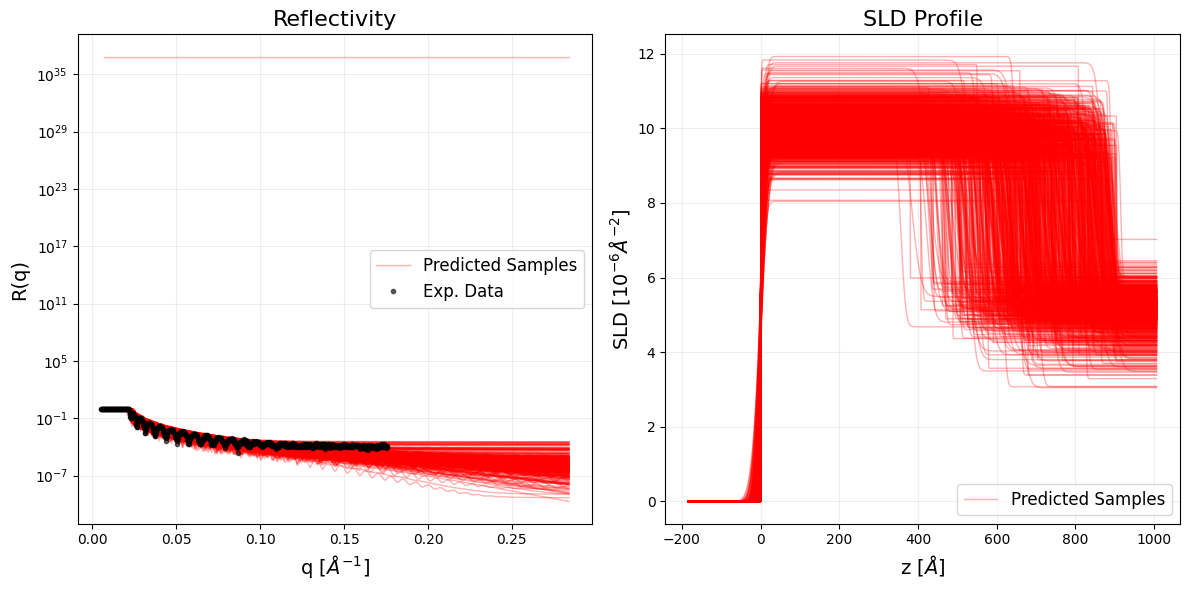

In [17]:
postprocess(prediction_dict)

In [ ]:
# # from previous reflectorch results:
# Thickness L1   -> Predicted: 812.66       Polished: 826.98
# Roughness L1   -> Predicted: 8.42       Polished: 8.14
# Roughness sub  -> Predicted: 1.35       Polished: 0.00
# SLD L1         -> Predicted: 9.05       Polished: 9.17
# SLD sub        -> Predicted: 3.85       Polished: 4.00
# r_scale        -> Predicted: 0.97       Polished: 0.91
# log10_background -> Predicted: -4.17       Polished: -4.00

## Inference with likelihoods and importance sampling

In [18]:
prediction_dict = inference_model.preprocess_and_sample(
    reflectivity_curve=exp_curve_interp,
    q_values=q_model, 
    num_samples=10000, 
    prior_bounds=prior_bounds, 
    q_resolution=0.015, # was 0.1 in the previous example
    calc_sampled_curves=True, 
    calc_sampled_sld_profiles=True,
    calc_log_likelihoods=True,
    enable_importance_sampling=True)


################################################################################
### STARTING INFERENCE SAMPLE() METHOD ###
################################################################################

[sample] Prior bounds shape: (7, 2)
[sample] Scaled prior bounds dtype: torch.float32, shape: torch.Size([1, 14])

[sample] ========== PREPROCESSING INPUTS ==========

[sample] Using ConstantQ generator

[sample] Calling _scale_curve()...
[sample] scaled_curve output:
  - dtype: torch.float32, shape: torch.Size([1, 256])
  - range: [-6.011904e-02, 9.460456e-01]

[sample] Computing scaled_q_values (train_with_q_input=True)...
  - Before dtype conversion: torch.float64
  - After dtype conversion: torch.float32
  - shape: torch.Size([1, 256])
  - range: [-1.000000e+00, 1.000000e+00]

[sample] scaled_sigmas = None (train_with_sigmas=False, sigmas=None)
[DEBUG] q_resolution is scalar: 0.015
[DEBUG] scaled_q_resolutions dtype: torch.float32
[DEBUG] FINAL scaled_conditioning_params dtype: 

In [19]:
prediction_dict

{'predicted_params_object': BasicParams(batch_size=10000, max_layer_num=1, device=cpu),
 'predicted_params_array': array([[ 8.52295616e+02, -7.32850985e-02,  5.61525550e+00, ...,
          5.68341216e+00,  9.94459432e-01, -5.88052893e+00],
        [ 6.50233683e+02,  8.74383874e+00, -1.92278612e+00, ...,
          4.76372430e+00,  9.89162576e-01, -8.66029596e+00],
        [ 4.54591635e+02,  4.58811375e+00, -1.93095196e-02, ...,
          5.35269884e+00,  9.91598642e-01, -1.03468990e+01],
        ...,
        [ 5.46208942e+02,  2.09642696e+00,  1.63543942e+01, ...,
          4.91218900e+00,  9.97011697e-01, -1.05043941e+01],
        [ 6.75904820e+02,  9.15473645e-01,  1.49839059e+01, ...,
          5.22929194e+00,  9.68381637e-01, -5.98100376e+00],
        [ 4.24876477e+02,  1.82335902e+00, -1.15618103e+00, ...,
          4.94435882e+00,  9.58987844e-01, -8.16550350e+00]]),
 'param_names': ['Thickness L1',
  'Roughness L1',
  'Roughness sub',
  'SLD L1',
  'SLD sub',
  'r_scale',
  'log1

Best Sample Index: 181 (LogL: -211.7593)
Worst Sample Index: 6330 (LogL: -47527087837247841839478241208321605059493995204072028869437548064494696274608017605660588969166777765330944.0000)

Parameter Comparison:
Parameter            | Best Case    | Worst Case  
--------------------------------------------------
Thickness L1         | 819.9983     | 896.0098    
Roughness L1         | 5.1468       | 2.4946      
Roughness sub        | 0.0440       | 16.8099     
SLD L1               | 8.7431       | 10.8123     
SLD sub              | 4.2045       | 5.4954      
r_scale              | 0.9818       | 0.9911      
log10_background     | -4.0343      | 47.6548     


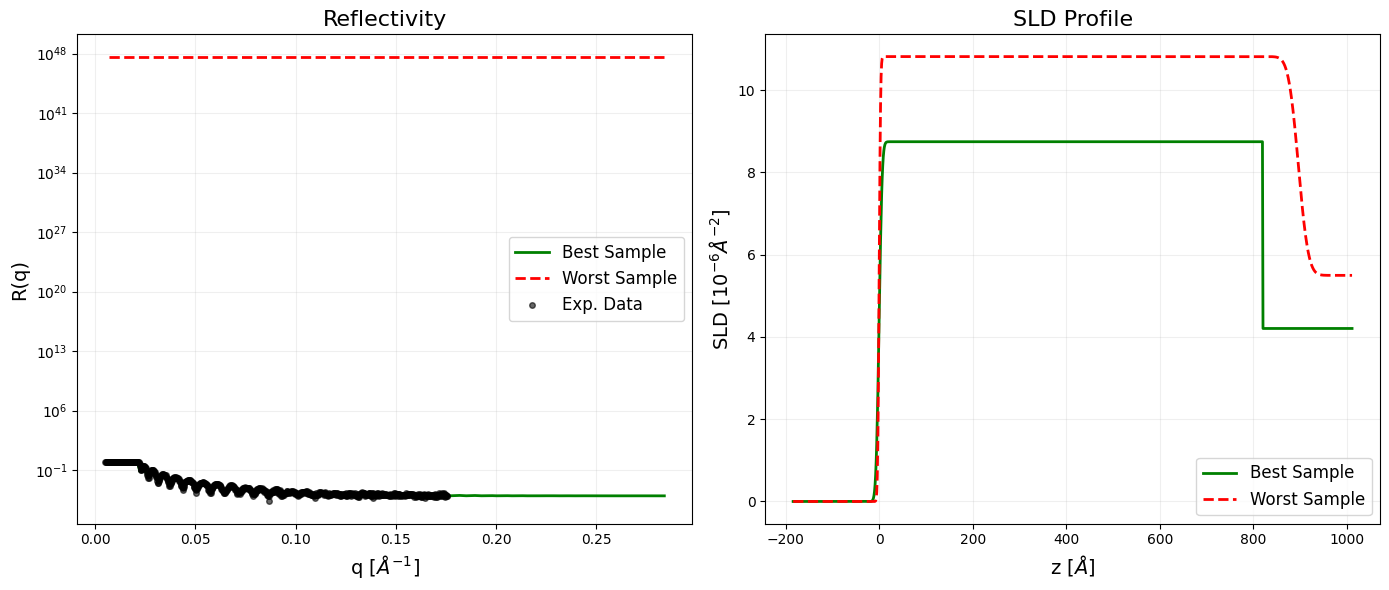

In [20]:
# ...existing code...
def postprocess_extremes(prediction_dict, best_idx=None, worst_idx=None):
    # Extract data
    log_likelihoods = prediction_dict.get('log_likelihoods')
    pred_params = prediction_dict['predicted_params_array']
    param_names = prediction_dict['param_names']
    
    sampled_curves = prediction_dict['sampled_curves']
    sampled_slds = prediction_dict['sampled_sld_profiles']
    
    q_plot = prediction_dict['q_plot_pred']
    sld_xaxis = prediction_dict['sampled_sld_xaxis']

    # Determine indices if not provided
    if log_likelihoods is not None:
        if best_idx is None:
            best_idx = np.argmax(log_likelihoods)
        if worst_idx is None:
            worst_idx = np.argmin(log_likelihoods)
        
        print(f"Best Sample Index: {best_idx} (LogL: {log_likelihoods[best_idx]:.4f})")
        print(f"Worst Sample Index: {worst_idx} (LogL: {log_likelihoods[worst_idx]:.4f})")
    else:
        print("Warning: 'log_likelihoods' not found. Using first and last samples.")
        best_idx = 0
        worst_idx = -1

    # 1. Print Parameters
    print("\nParameter Comparison:")
    print(f"{'Parameter':<20} | {'Best Case':<12} | {'Worst Case':<12}")
    print("-" * 50)
    for i, name in enumerate(param_names):
        val_best = pred_params[best_idx, i]
        val_worst = pred_params[worst_idx, i]
        print(f"{name:<20} | {val_best:<12.4f} | {val_worst:<12.4f}")

    # 2. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # --- Left Plot: Reflectivity ---
    ax[0].set_yscale('log')
    ax[0].set_xlabel('q [$Å^{-1}$]', fontsize=14)
    ax[0].set_ylabel('R(q)', fontsize=14)
    ax[0].set_title('Reflectivity', fontsize=16)

    # Plot Experimental Data (Ground Truth)
    ax[0].errorbar(q_exp, curve_exp, fmt='o', color='black', 
                markersize=4, alpha=0.6, label='Exp. Data', zorder=10)

    # Plot Best and Worst curves
    ax[0].plot(q_plot, sampled_curves[best_idx], color='green', linewidth=2, label='Best Sample')
    ax[0].plot(q_plot, sampled_curves[worst_idx], color='red', linestyle='--', linewidth=2, label='Worst Sample')

    ax[0].legend(fontsize=12)
    ax[0].grid(alpha=0.2, which='both')

    # --- Right Plot: SLD Profile ---
    ax[1].set_xlabel('z [$Å$]', fontsize=14)
    ax[1].set_ylabel('SLD [$10^{-6} Å^{-2}$]', fontsize=14)
    ax[1].set_title('SLD Profile', fontsize=16)

    # Plot Best and Worst SLDs
    ax[1].plot(sld_xaxis, sampled_slds[best_idx], color='green', linewidth=2, label='Best Sample')
    ax[1].plot(sld_xaxis, sampled_slds[worst_idx], color='red', linestyle='--', linewidth=2, label='Worst Sample')

    ax[1].legend(fontsize=12)
    ax[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# Run the function
postprocess_extremes(prediction_dict)

# Testing on Alexandros' data

In [21]:
!pwd

/home/levytskyi/Documents/reflectorch_devvm/reflectorch


In [22]:
data = np.loadtxt('exp_data/s000004_experimental_curve.dat', skiprows=1)
print(data.shape)

q_exp = data[..., 0]
curve_exp = data[..., 1]
sigmas_exp = data[..., 2]
q_res_exp = data[..., 3]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())
print(sigmas_exp.shape, sigmas_exp.max(), sigmas_exp.min(), (sigmas_exp / curve_exp).max())
print(q_res_exp.shape, (q_res_exp / q_exp).min(), (q_res_exp / q_exp).max())

(76, 4)
(76,) (76,) 0.0070072 0.283544
(76,) 0.0154092 1.01647e-06 24.521023810098182
(76,) 0.09999999999999998 0.10000000000000002


In [23]:
#layer        sld(A^-2)   thickness(A) roughness(A)  
# fronting      3.50000e-06      inf      8.04
# layer1        3.56709e-06      28.63      7.04
# backing       9.79867e-06      inf       none

prior_bounds = [
    (10., 50.), #layer thicknesses (top to bottom)
    (0., 15.), (0., 15.), #interlayer roughnesses (top to bottom)
    (3.0, 4.0), (9.0, 11.0), #layer slds: L1, Backing
    (0.9, 1.1), #intensity scaling factor
    (-10, -4), #log10 background
] 

In [42]:
# q_model, exp_curve_interp = inference_model.interpolate_data_to_model_q(q_exp, curve_exp)

# print(q_model.shape, q_model.min(), q_model.max())
# print(exp_curve_interp.shape)

In [24]:
# Cell: Interpolate both curve AND sigmas
q_model, exp_curve_interp, sigmas_interp = inference_model.interpolate_data_to_model_q(
    q_exp, curve_exp,
    sigmas_exp=sigmas_exp  # ← Add this parameter
)

print(q_model.shape, q_model.min(), q_model.max())
print(exp_curve_interp.shape)
print(sigmas_interp.shape)  # ← Verify sigmas were interpolated

(256,) 0.007 0.284
(256,)
(256,)


In [25]:
q_res_interp = np.interp(q_model, q_exp, q_res_exp) #pointwise resolution smearing
print(q_res_exp.shape, q_res_interp.shape, q_res_exp.shape, (q_res_interp / q_model).min(), (q_res_interp / q_model).max())

(76,) (256,) (76,) 0.09983943661971831 0.10010285714285715


In [26]:
prediction_dict = inference_model.preprocess_and_sample(
    reflectivity_curve=exp_curve_interp,
    q_values=q_model,
    sigmas=sigmas_interp,
    q_resolution=q_res_interp,
    num_samples=1000, #system crashes with 10.000 
    prior_bounds=prior_bounds, 
    calc_sampled_curves=True, 
    calc_sampled_sld_profiles=True,
    calc_log_likelihoods=True,
    enable_importance_sampling=True)


################################################################################
### STARTING INFERENCE SAMPLE() METHOD ###
################################################################################

[sample] Prior bounds shape: (7, 2)
[sample] Scaled prior bounds dtype: torch.float32, shape: torch.Size([1, 14])

[sample] ========== PREPROCESSING INPUTS ==========

[sample] Using ConstantQ generator

[sample] Calling _scale_curve()...
[sample] scaled_curve output:
  - dtype: torch.float32, shape: torch.Size([1, 256])
  - range: [-4.473615e-02, 9.653201e-01]

[sample] Computing scaled_q_values (train_with_q_input=True)...
  - Before dtype conversion: torch.float64
  - After dtype conversion: torch.float32
  - shape: torch.Size([1, 256])
  - range: [-1.000000e+00, 1.000000e+00]

[sample] scaled_sigmas = None (train_with_sigmas=False, sigmas=provided)
[DEBUG] Converted q_resolution from numpy (float64) to tensor (torch.float32)
[DEBUG] q_values dtype before division: torch.float64


Best Sample Index: 76 (LogL: -44228.3597)
Worst Sample Index: 982 (LogL: -159042.0772)

Parameter Comparison:
Parameter            | Best Case    | Worst Case  
--------------------------------------------------
Thickness L1         | 50.4417      | 11.1799     
Roughness L1         | 0.4441       | 1.7715      
Roughness sub        | 13.2590      | 0.0364      
SLD L1               | 4.1088       | 3.3848      
SLD sub              | 8.6421       | 8.6468      
r_scale              | 0.9829       | 0.9924      
log10_background     | -6.2105      | -6.2467     


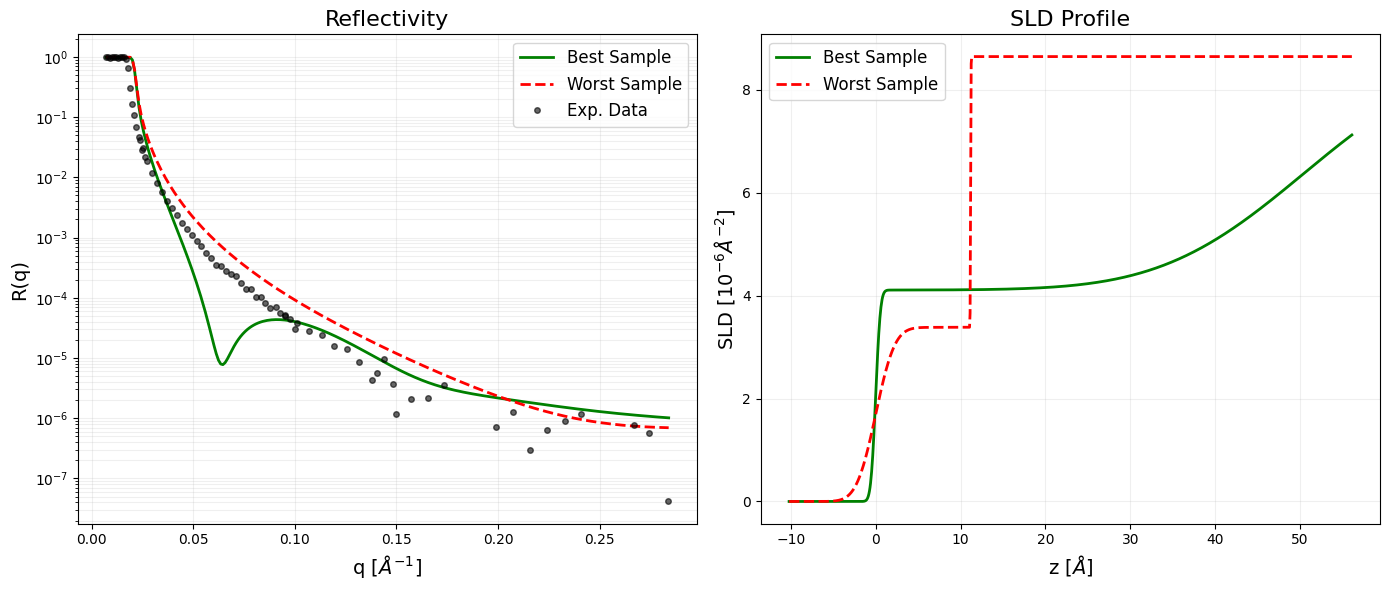

In [27]:
postprocess_extremes(prediction_dict)

In [30]:
prediction_dict.keys()

dict_keys(['predicted_params_object', 'predicted_params_array', 'param_names', 'sampled_curves', 'q_plot_pred', 'log_likelihoods', 'unscaled_log_prob', 'weights', 'ess', 'log_evidence', 'sampled_sld_profiles', 'sampled_sld_xaxis', 'q_model', 'reflectivity_curve_interp', 'q_resolution_interp', 'sigmas_interp'])

In [38]:
prediction_dict['log_evidence']

-44243.851510811815